# Оцифровка персонажа

In [6]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import transfer_color, extract_colored

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Флоу A — известный контур (перенос цвета)

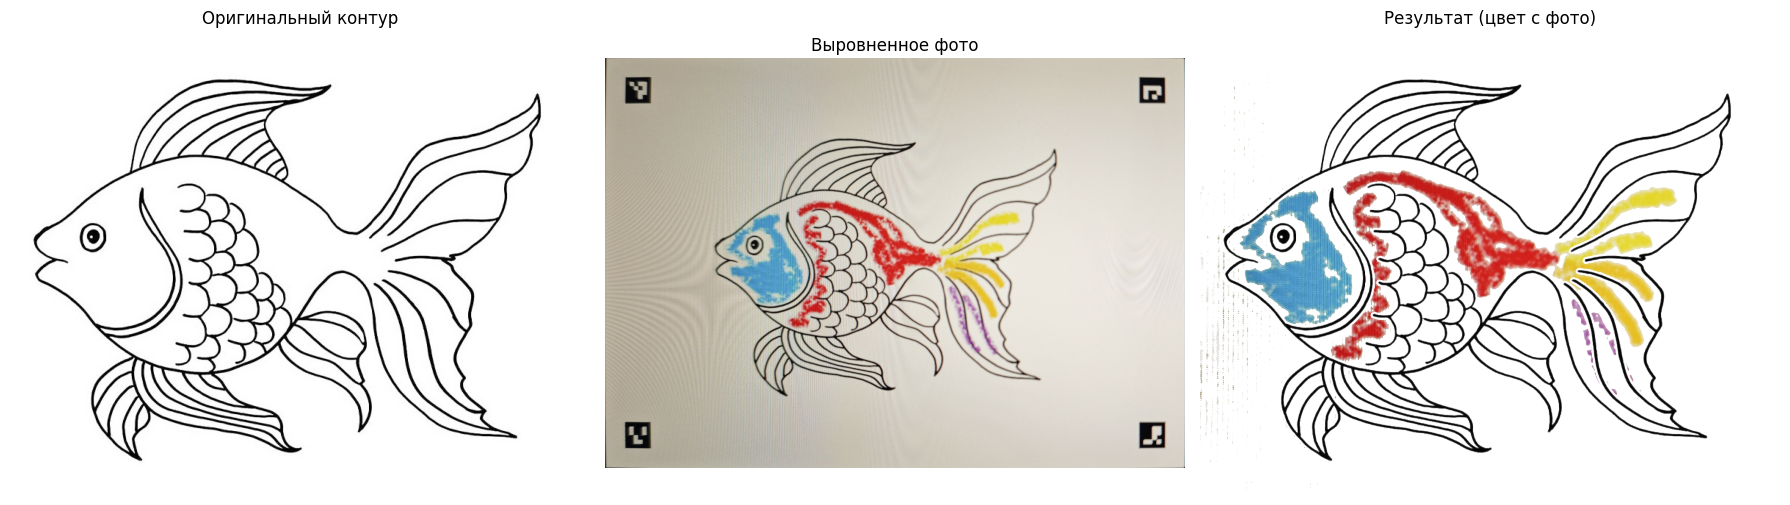

True

In [4]:
meta = json.load(open("output/img01_raw_meta.json"))
aligned = cv2.imread("output/img01_photo_aligned.jpg")

res = transfer_color(aligned, "input/img01_raw.jpg", meta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread("input/img01_raw.jpg"), cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинальный контур")
axes[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
axes[1].set_title("Выровненное фото")
axes[2].imshow(res["rgba"][:, :, [2,1,0,3]])
axes[2].set_title("Результат (цвет с фото)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

cv2.imwrite("output/img01_photo_aligned_digitized.png", res["rgba"])

## Флоу B — произвольный рисунок (пустой шаблон)

Вход: фото рисунка на пустом шаблоне → выравнивание → сегментация → RGBA.

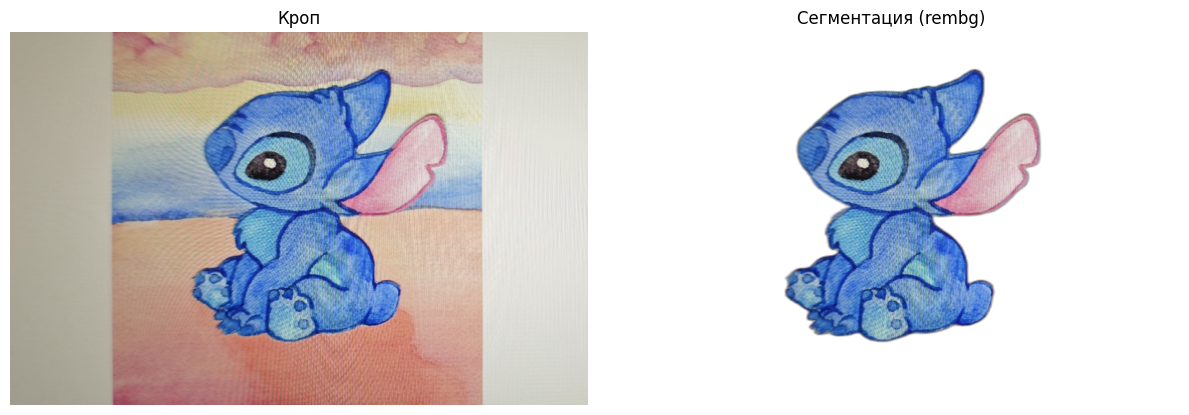

True

In [9]:
from rembg import remove

aligned = cv2.imread("output/img04_photo_aligned.jpg")
x, y, w, h = meta["drawing_bbox"]
crop = aligned[y:y+h, x:x+w]

# rembg работает с RGB PIL/numpy
rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
result = remove(rgb)  # → RGBA numpy array

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb)
axes[0].set_title("Кроп")
axes[1].imshow(result)
axes[1].set_title("Сегментация (rembg)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# сохраняем RGBA
result_bgra = cv2.cvtColor(result, cv2.COLOR_RGBA2BGRA)
cv2.imwrite("output/img04_photo_aligned_digitized.png", result_bgra)